In [1]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import keras_tuner as kt
import keras

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

2025-06-09 09:43:24.249473: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749462204.473569      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749462204.539903      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
#!rm -rf /kaggle/working/best_model_LSTM.h5 /kaggle/working/best_model_LSTM_LOAD.h5 /kaggle/working/my_dir.zip

In [3]:
df = pd.read_csv('/kaggle/input/diesel-price-weekly/diesel_weekly.csv')

In [4]:
df.drop(columns=['Weekly  Diesel Prices   (Dollars per Gallon)'], inplace=True, axis=1)
df.rename(columns={'Weekly  Diesel Prices  (MAD per Litter)': 'Price'}, inplace=True)

In [5]:
df['Date'] = pd.to_datetime(df['Date'])

In [6]:
df

,Date,Price
0,1994-03-21,2.921743
1,1994-03-28,2.924385
2,1994-04-04,2.929668
3,1994-04-11,2.927026
4,1994-04-18,2.919101
...,...,...
1615,2025-03-03,9.602654
1616,2025-03-10,9.462643
1617,2025-03-17,9.375466
1618,2025-03-24,9.423017


In [7]:
df.head(24)

,Date,Price
0,1994-03-21,2.921743
1,1994-03-28,2.924385
2,1994-04-04,2.929668
3,1994-04-11,2.927026
4,1994-04-18,2.919101
5,1994-04-25,2.921743
6,1994-05-02,2.916459
7,1994-05-09,2.908534
8,1994-05-16,2.903251
9,1994-05-23,2.903251


In [8]:
def create_dataset(serie, time_steps=1):
    Xs, ys = [], []
    for i in range(len(serie) - time_steps):
        Xs.append(serie.iloc[i:(i + time_steps)].values)
        ys.append(serie.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)


In [9]:
scaler = MinMaxScaler(feature_range=(0,1))

In [10]:
time_steps = 15
X, y = create_dataset(df.Price, time_steps)
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.reshape(-1,1))

In [11]:
names = [f"X{i}" for i in range(15)]
data = pd.DataFrame(X_scaled, columns=names)
data["Y"] = y_scaled
data.head()

,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,Y
0,0.031501,0.031707,0.032119,0.031913,0.031295,0.031501,0.031089,0.030471,0.030060,0.030060,0.029854,0.030471,0.029854,0.030883,0.031913,0.032119
1,0.031707,0.032119,0.031913,0.031295,0.031501,0.031089,0.030471,0.030060,0.030060,0.029854,0.030471,0.029854,0.030883,0.031913,0.032119,0.032324
2,0.032119,0.031913,0.031295,0.031501,0.031089,0.030471,0.030060,0.030060,0.029854,0.030471,0.029854,0.030883,0.031913,0.032119,0.032324,0.032530
3,0.031913,0.031295,0.031501,0.031089,0.030471,0.030060,0.030060,0.029854,0.030471,0.029854,0.030883,0.031913,0.032119,0.032324,0.032530,0.032530
4,0.031295,0.031501,0.031089,0.030471,0.030060,0.030060,0.029854,0.030471,0.029854,0.030883,0.031913,0.032119,0.032324,0.032530,0.032530,0.033560


In [12]:
X.shape

(1605, 15)

In [13]:
X_resh = X_scaled.reshape(len(X), time_steps,1)

In [14]:
X_temp, X_test, y_temp, y_test = train_test_split(X_resh, y_scaled,test_size = 0.1, random_state=42, shuffle=False)

In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, shuffle=False
)

In [16]:
window_size = time_steps

In [17]:
val_loss = {
    'Simple RNN': 0,
    'LSTM': 0,
    'BILSTM': 0,
    'GRU': 0
}

In [18]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'),
 PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

In [19]:
#!rm -rf /kaggle/working/my_dir

In [20]:
import tensorflow as tf
import keras_tuner as kt
from tensorflow import keras


# this is for the GPU
strategy = tf.distribute.MirroredStrategy()

print(f"Number of devices: {strategy.num_replicas_in_sync}")

    
def model_builder_simpleRNN(hp):
    model = tf.keras.Sequential()

    # hyperparameters
    hp_units = hp.Int('units', min_value=32, max_value=512, step=32)
    hp_activation = hp.Choice('activation', ['relu', 'tanh'])

    model.add(tf.keras.layers.SimpleRNN(units=hp_units, activation=hp_activation, input_shape=(window_size, 1)))
    model.add(tf.keras.layers.Dense(1, activation='relu'))

    hp_learning_rate = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='mse')

    return model

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# run the search with GPU
with strategy.scope():
    tuner_simRNN = kt.Hyperband(
        model_builder_simpleRNN,
        objective='val_loss',
        max_epochs=10,
        factor=3,
        directory='my_dir',
        project_name='simpleRNN'
    )


tuner_simRNN.search(X_train, y_train, epochs=50, validation_data=(X_val, y_val), callbacks=[stop_early])

best_hps_simRNN = tuner_simRNN.get_best_hyperparameters(num_trials=1)[0]
best_trial_simRNN = tuner_simRNN.oracle.get_best_trials(num_trials=1)[0]
val_loss = {}
val_loss['Simple RNN'] = best_trial_simRNN.metrics.get_best_value('val_loss')

print("="*100)
print(f"""
The validation loss is: {val_loss['Simple RNN']:.6f}
Best number of units: {best_hps_simRNN.get('units')}
Best learning rate: {best_hps_simRNN.get('learning_rate')}
Best activation: {best_hps_simRNN.get('activation')}
""")


Trial 30 Complete [00h 00m 06s]
val_loss: 0.00018878508126363158

Best val_loss So Far: 4.785479177371599e-05
Total elapsed time: 00h 02m 36s

The validation loss is: 0.000048
Best number of units: 160
Best learning rate: 0.01
Best activation: relu



In [21]:
import tensorflow as tf
import keras_tuner as kt
from tensorflow import keras


# this is for the GPU
strategy = tf.distribute.MirroredStrategy()

print(f"Number of devices: {strategy.num_replicas_in_sync}")


def model_builder_lstm(hp):
    model = tf.keras.models.Sequential()

    hp_units = hp.Int('units', min_value=32, max_value=512, step=32)
    hp_activation = hp.Choice('activation', values=['relu', 'tanh'])

    model.add(tf.keras.layers.LSTM(units=hp_units, activation=hp_activation, input_shape=(window_size, 1)))
    model.add(tf.keras.layers.Dense(1, activation='relu'))  # Output layer

    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='mse'
    )

    return model


stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)


with strategy.scope():
    tuner_LSTM = kt.Hyperband(
        model_builder_lstm,
        objective='val_loss',
        max_epochs=10,
        factor=3,
        directory='my_dir',
        project_name='lstm'
    )

# run the search with GPU
tuner_LSTM.search(X_train, y_train, epochs=50, validation_data=(X_val, y_val),
    callbacks=[stop_early]
)

# Retrieve best hyperparameters and validation loss
best_hps_LSTM = tuner_LSTM.get_best_hyperparameters(num_trials=1)[0]
best_trial_LSTM = tuner_LSTM.oracle.get_best_trials(num_trials=1)[0]

val_loss['LSTM'] = best_trial_LSTM.metrics.get_best_value('val_loss')

print("="*100)
print(f"""
LSTM Validation Loss: {val_loss['LSTM']:.6f}
Optimal Units: {best_hps_LSTM.get('units')}
Optimal Learning Rate: {best_hps_LSTM.get('learning_rate')}
Optimal Activation: {best_hps_LSTM.get('activation')}
""")


Trial 30 Complete [00h 00m 09s]
val_loss: 0.18353456258773804

Best val_loss So Far: 0.00016723002772778273
Total elapsed time: 00h 02m 50s

LSTM Validation Loss: 0.000167
Optimal Units: 128
Optimal Learning Rate: 0.001
Optimal Activation: tanh



In [22]:
import tensorflow as tf
import keras_tuner as kt
from tensorflow import keras


# this is for the GPU
strategy = tf.distribute.MirroredStrategy()

print(f"Number of devices: {strategy.num_replicas_in_sync}")


def model_builder_Bilstm(hp):
    model = tf.keras.models.Sequential()

    hp_units = hp.Int('units', min_value=32, max_value=512, step=32)
    hp_activation = hp.Choice('activation', values=['relu', 'tanh']) 

    model.add(tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(units=hp_units, activation=hp_activation),
        input_shape=(window_size, 1)
    ))
    model.add(tf.keras.layers.Dense(1, activation='relu')) 

    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='mse'
    )

    return model


stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)


# run the search with GPU
with strategy.scope():

    tuner_Bidirectional = kt.Hyperband(
    model_builder_Bilstm,
    objective='val_loss',
    max_epochs=10,
    factor=3,
    directory='my_dir',
    project_name='Bilstm'
    )
    
tuner_Bidirectional.search(
    X_train, y_train, epochs=50, validation_data=(X_val, y_val),
    callbacks=[stop_early]
)


best_hps_Bidirectional = tuner_Bidirectional.get_best_hyperparameters(num_trials=1)[0]
best_trial_Bidirectional = tuner_Bidirectional.oracle.get_best_trials(num_trials=1)[0]
val_loss['BILSTM'] = best_trial_Bidirectional.metrics.get_best_value('val_loss')

print("="*100)
print(f"""
BiLSTM Validation Loss: {val_loss['BILSTM']:.6f}
Optimal Units: {best_hps_Bidirectional.get('units')}
Optimal Learning Rate: {best_hps_Bidirectional.get('learning_rate')}
Optimal Activation: {best_hps_Bidirectional.get('activation')}
""")


Trial 30 Complete [00h 00m 09s]
val_loss: 0.000768093450460583

Best val_loss So Far: 0.00013452157145366073
Total elapsed time: 00h 04m 44s

BiLSTM Validation Loss: 0.000135
Optimal Units: 32
Optimal Learning Rate: 0.01
Optimal Activation: relu



In [23]:
import tensorflow as tf
import keras_tuner as kt
from tensorflow import keras

# this is for the GPU
strategy = tf.distribute.MirroredStrategy()

print(f"Number of devices: {strategy.num_replicas_in_sync}")


def model_builder_gru(hp):
    model = tf.keras.models.Sequential()

    hp_units = hp.Int('units', min_value=32, max_value=512, step=32)
    hp_activation = hp.Choice('activation', values=['relu', 'tanh'])

    model.add(tf.keras.layers.Reshape((window_size, 1), input_shape=[window_size]))
    model.add(tf.keras.layers.GRU(units=hp_units, activation=hp_activation))
    model.add(tf.keras.layers.Dense(1, activation='relu'))

    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='mse')
    return model

# run the search with GPU
with strategy.scope():
    tuner_GRU = kt.Hyperband(
        model_builder_gru,
        objective='val_loss',
        max_epochs=10,
        factor=3,
        directory='my_dir',
        project_name='gru'
    )


tuner_GRU.search(X_train, y_train, epochs=50, validation_data=(X_val, y_val), callbacks=[stop_early])

best_hps_GRU = tuner_GRU.get_best_hyperparameters(num_trials=1)[0]
best_trial_GRU = tuner_GRU.oracle.get_best_trials(num_trials=1)[0]
val_loss['GRU'] = best_trial_GRU.metrics.get_best_value('val_loss')

print("="*100)
print(f"""
GRU Validation Loss: {val_loss['GRU']}
Optimal Units: {best_hps_GRU.get('units')}
Optimal Learning Rate: {best_hps_GRU.get('learning_rate')}
Optimal Activation: {best_hps_GRU.get('activation')}
""")


Trial 30 Complete [00h 00m 07s]
val_loss: 0.18353456258773804

Best val_loss So Far: 5.205922934692353e-05
Total elapsed time: 00h 03m 39s

GRU Validation Loss: 5.205922934692353e-05
Optimal Units: 64
Optimal Learning Rate: 0.01
Optimal Activation: relu



In [24]:
val_loss

{'Simple RNN': 4.785479177371599e-05,
 'LSTM': 0.00016723002772778273,
 'BILSTM': 0.00013452157145366073,
 'GRU': 5.205922934692353e-05}

In [25]:
best_model_rnn = tuner_simRNN.get_best_models(num_models=1)[0]
best_model_lstm = tuner_LSTM.get_best_models(num_models=1)[0]
best_model_bilstm = tuner_Bidirectional.get_best_models(num_models=1)[0]
best_model_gru = tuner_GRU.get_best_models(num_models=1)[0]

best_hp_rnn = tuner_simRNN.get_best_hyperparameters(num_trials=1)[0]
best_hp_lstm = tuner_LSTM.get_best_hyperparameters(num_trials=1)[0]
best_hp_bilstm = tuner_Bidirectional.get_best_hyperparameters(num_trials=1)[0]
best_hp_gru = tuner_GRU.get_best_hyperparameters(num_trials=1)[0]

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model_hp_pairs = [
    (best_model_rnn, best_hp_rnn),
    (best_model_lstm, best_hp_lstm),
    (best_model_bilstm, best_hp_bilstm),
    (best_model_gru, best_hp_gru)
]

histories = []
best_models = []

for model, hp in model_hp_pairs:
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp.get('learning_rate')),
        loss='mse'
    )
    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping],
        verbose=1
    )
    best_models.append(model)
    histories.append(history)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0031 - val_loss: 1.0401e-04
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.3849e-04 - val_loss: 1.4377e-04
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0306e-04 - val_loss: 3.3786e-05
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.8467e-05 - val_loss: 3.5714e-05
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.3396e-05 - val_loss: 8.7374e-05
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.7968e-05 - val_loss: 1.9845e-04
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.8091e-05 - val_loss: 3.2337e-05
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.2030e-05 - val_loss: 1.3138e-04
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.0425e-05 - val_loss: 4.2872e-05
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.1510e-05 - val_loss: 6.7387e-05
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.7358e-05 -

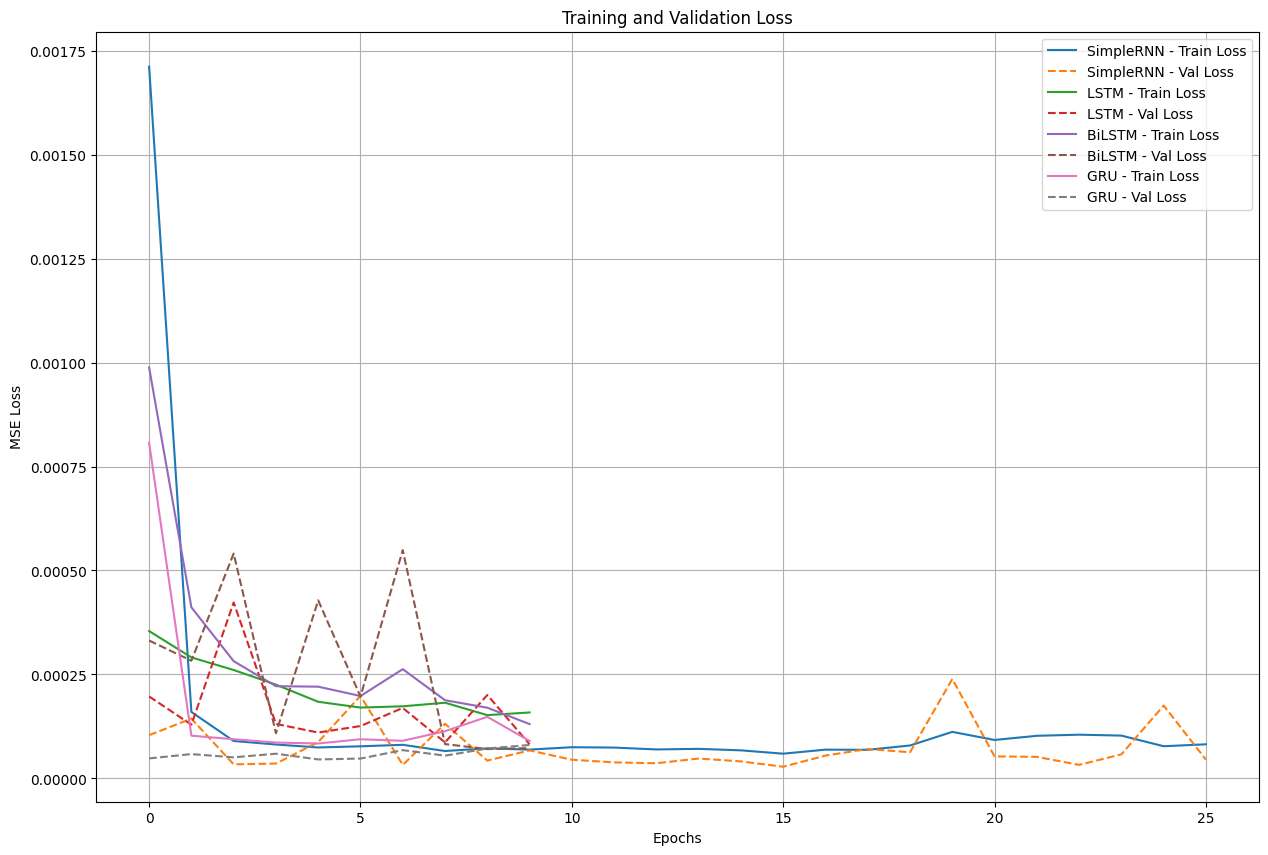

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


<Figure size 1500x1000 with 0 Axes>

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.metrics import mean_absolute_error

model_names = ['SimpleRNN', 'LSTM', 'BiLSTM', 'GRU']
r2_scores = {}
mse_scores = {}
mae_scores = {}

plt.figure(figsize=(15, 10))
for i, history in enumerate(histories):
    plt.plot(history.history['loss'], label=f'{model_names[i]} - Train Loss')
    plt.plot(history.history['val_loss'], label=f'{model_names[i]} - Val Loss', linestyle='--')
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()


for i, model in enumerate(best_models):
    y_preds = model.predict(X_test).flatten()
    
    mse = mean_squared_error(y_test, y_preds)
    mae = mean_absolute_error(y_test, y_preds)
    r2 = r2_score(y_test, y_preds)

    r2_scores[model_names[i]] = r2
    mse_scores[model_names[i]] = mse
    mae_scores[model_names[i]] = mae
plt.figure(figsize=(15, 10))

r2_scores = {}
mse_scores = {}
mae_scores = {}

for i, model in enumerate(best_models):
    y_preds = model.predict(X_test).flatten()

    r2_scores[model_names[i]] = r2_score(y_test, y_preds)
    mse_scores[model_names[i]] = mean_squared_error(y_test, y_preds)
    mae_scores[model_names[i]] = mean_absolute_error(y_test, y_preds)


results = pd.DataFrame({
    'model': list(r2_scores.keys()),
    'r2': list(r2_scores.values()),
    'mse': list(mse_scores.values()),
    'mae': list(mae_scores.values())
})


In [28]:
results

,model,r2,mse,mae
0,SimpleRNN,0.978012,0.000398,0.012289
1,LSTM,0.929942,0.001268,0.022604
2,BiLSTM,0.891884,0.001957,0.031265
3,GRU,0.970368,0.000536,0.016061


All of the model performed well so we will choose the best one based on their mse

In [29]:
import joblib


use_r2 = False

if use_r2:
    best_model_name = max(r2_scores, key=r2_scores.get)
    best_model_index = model_names.index(best_model_name)
    print(f"Best model based on R²: {best_model_name} ({r2_scores[best_model_name]:.6f})")
else:
    best_model_name = min(mse_scores, key=mse_scores.get)
    best_model_index = model_names.index(best_model_name)
    print(f"Best model based on MSE: {best_model_name} ({mse_scores[best_model_name]:.6f})")

best_model = best_models[best_model_index]

best_model.save(f'best_model_{best_model_name}.h5')
print(f"Model saved as best_model_{best_model_name}.h5")


Best model based on MSE: SimpleRNN (0.000398)
Model saved as best_model_SimpleRNN.h5


# Loaanding and testing the model

In [30]:
df

,Date,Price
0,1994-03-21,2.921743
1,1994-03-28,2.924385
2,1994-04-04,2.929668
3,1994-04-11,2.927026
4,1994-04-18,2.919101
...,...,...
1615,2025-03-03,9.602654
1616,2025-03-10,9.462643
1617,2025-03-17,9.375466
1618,2025-03-24,9.423017


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step


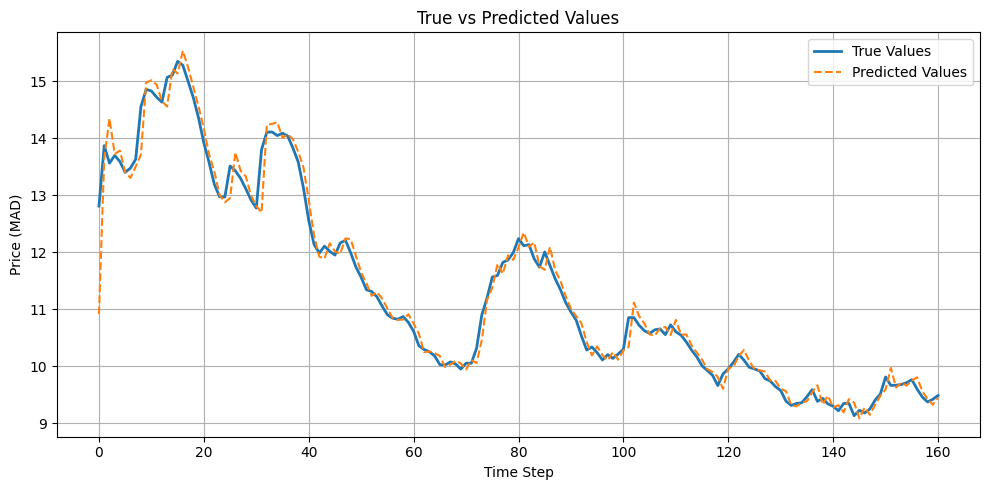

In [31]:
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
from tensorflow.keras.losses import MeanSquaredError

model = load_model('/kaggle/working/best_model_SimpleRNN.h5', custom_objects={'mse': MeanSquaredError()})
y_pred = model.predict(X_test).flatten()
# y_pred[y_pred < 0] = 0


plt.figure(figsize=(10, 5))
plt.plot(scaler.inverse_transform(y_test.reshape(-1,1)), label='True Values', linewidth=2)
plt.plot(scaler.inverse_transform(y_pred.reshape(-1,1)), label='Predicted Values', linestyle='--')
plt.title('True vs Predicted Values')
plt.xlabel('Time Step')
plt.ylabel('Price (MAD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# 1) Forcasting the 22 of future

In [32]:
future = pd.DataFrame()
future['Price'] = y_pred
future

,Price
0,0.654580
1,0.867169
2,0.921906
3,0.873371
4,0.877953
...,...
156,0.568227
157,0.549192
158,0.538358
159,0.530808


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step


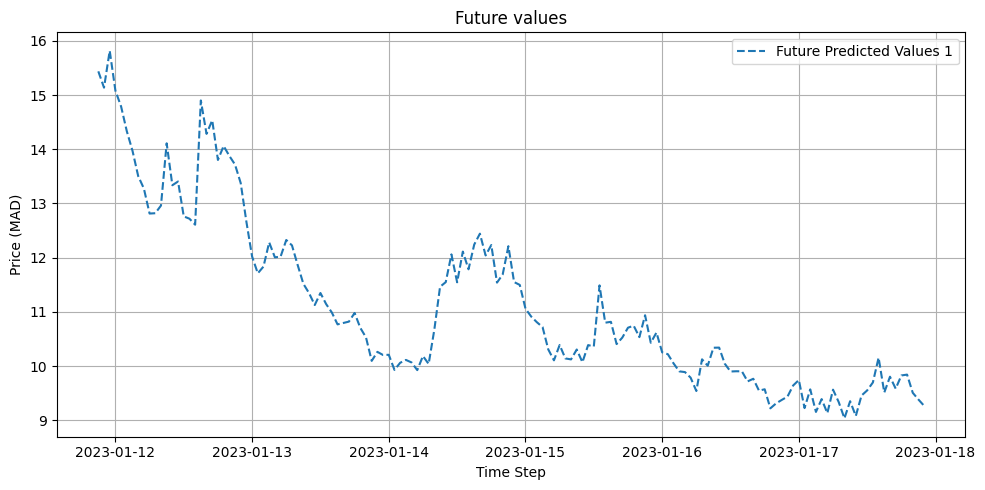

In [33]:
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
from tensorflow.keras.losses import MeanSquaredError


model = load_model('/kaggle/working/best_model_SimpleRNN.h5', custom_objects={'mse': MeanSquaredError()})
X, y = create_dataset(future.Price, time_steps)
y_pred1 = model.predict(X).flatten()
# y_pred1[y_pred1 < 0] = 0

plt.figure(figsize=(10, 5))
plt.plot(pd.date_range(start='2023-01-11 21:00:00', periods = len(y_pred1), freq='h'),scaler.inverse_transform(y_pred1.reshape(-1,1)), label='Future Predicted Values 1', linestyle='--')
plt.title('Future values')
plt.xlabel('Time Step')
plt.ylabel('Price (MAD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2) next 22 days

In [34]:
pd.date_range(start='2023-01-11 21:00:00', periods = len(y_pred1), freq='h')[-1]

Timestamp('2023-01-17 22:00:00')

In [35]:
future2 = pd.DataFrame()
future2['Price'] = y_pred1
future2

,Price
0,1.006970
1,0.983493
2,1.036626
3,0.979174
4,0.956376
...,...
141,0.569681
142,0.570892
143,0.544723
144,0.535027


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


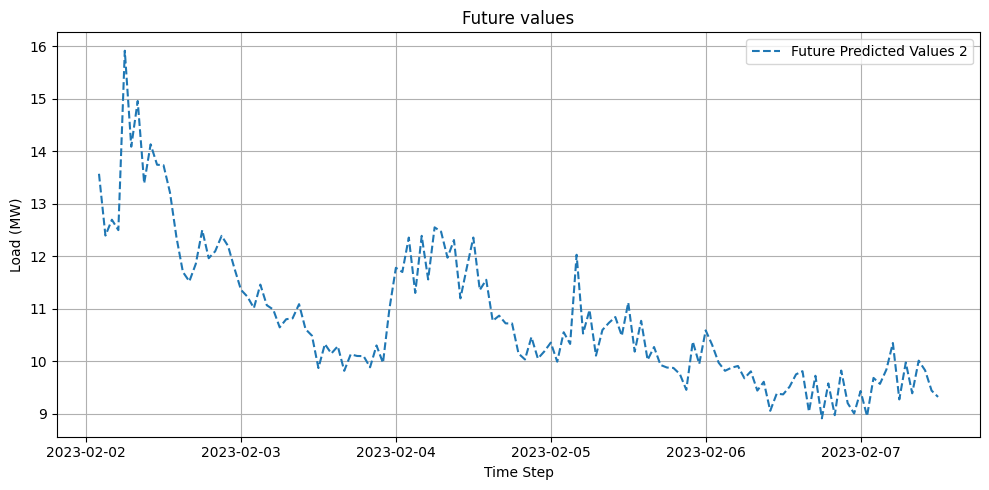

In [36]:
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
from tensorflow.keras.losses import MeanSquaredError

X, y = create_dataset(future2.Price, time_steps)
y_pred2 = model.predict(X).flatten()
# y_pred2[y_pred2 < 0] = 0

plt.figure(figsize=(10, 5))
plt.plot(pd.date_range(start='2023-02-02 02:00:00', periods = len(y_pred2), freq='h'),scaler.inverse_transform(y_pred2.reshape(-1,1)), label='Future Predicted Values 2', linestyle='--')
plt.title('Future values')
plt.xlabel('Time Step')
plt.ylabel('Load (MW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Saving model and directory

In [37]:
!zip -r /kaggle/working/my_dir.zip /kaggle/working/my_dir

  adding: kaggle/working/my_dir/ (stored 0%)
  adding: kaggle/working/my_dir/Bilstm/ (stored 0%)
  adding: kaggle/working/my_dir/Bilstm/trial_0028/ (stored 0%)
  adding: kaggle/working/my_dir/Bilstm/trial_0028/checkpoint.weights.h5 (deflated 29%)
  adding: kaggle/working/my_dir/Bilstm/trial_0028/build_config.json (stored 0%)
  adding: kaggle/working/my_dir/Bilstm/trial_0028/trial.json (deflated 58%)
  adding: kaggle/working/my_dir/Bilstm/trial_0029/ (stored 0%)
  adding: kaggle/working/my_dir/Bilstm/trial_0029/checkpoint.weights.h5 (deflated 6%)
  adding: kaggle/working/my_dir/Bilstm/trial_0029/build_config.json (stored 0%)
  adding: kaggle/working/my_dir/Bilstm/trial_0029/trial.json (deflated 58%)
  adding: kaggle/working/my_dir/Bilstm/trial_0023/ (stored 0%)
  adding: kaggle/working/my_dir/Bilstm/trial_0023/checkpoint.weights.h5 (deflated 20%)
  adding: kaggle/working/my_dir/Bilstm/trial_0023/build_config.json (stored 0%)
  adding: kaggle/working/my_dir/Bilstm/trial_0023/trial.json (

# Training the best model for more epochs

* Best number of units: 128
* Best learning rate: 0.001
* Best activation: relu



In [38]:
from tensorflow.keras.layers import Dense, SimpleRNN, Reshape
from tensorflow.keras import Sequential
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(SimpleRNN(units = 128, return_sequences=False, activation = 'relu',input_shape=(window_size, 1)))
model.add(Dense(1, activation = 'relu'))

model.compile(optimizer=Adam(learning_rate = 0.001), loss = 'mse', metrics = ['mae'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [39]:
from tensorflow.keras.callbacks import EarlyStopping


early_stopping = EarlyStopping(
    monitor='val_loss',  
    patience=20,          
    restore_best_weights=True 
)


history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,          
    batch_size=32,       
    callbacks=[early_stopping]  
)


Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0437 - mae: 0.1332 - val_loss: 6.8386e-04 - val_mae: 0.0233
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3442e-04 - mae: 0.0129 - val_loss: 1.2078e-04 - val_mae: 0.0089
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7557e-04 - mae: 0.0089 - val_loss: 9.6797e-05 - val_mae: 0.0078
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4764e-04 - mae: 0.0083 - val_loss: 9.5516e-05 - val_mae: 0.0078
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3019e-04 - mae: 0.0076 - val_loss: 7.9816e-04 - val_mae: 0.0265
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.4922e-04 - mae: 0.0141 - val_loss: 1.5037e-04 - val_mae: 0.0105
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3609e-04 - mae: 0.0079 - val_loss: 2.3873e-04 - val_mae: 0.0129
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8674e-04 - mae: 0.0090 - val_loss: 1.1667e-04 - val_mae: 0.0080
Epo

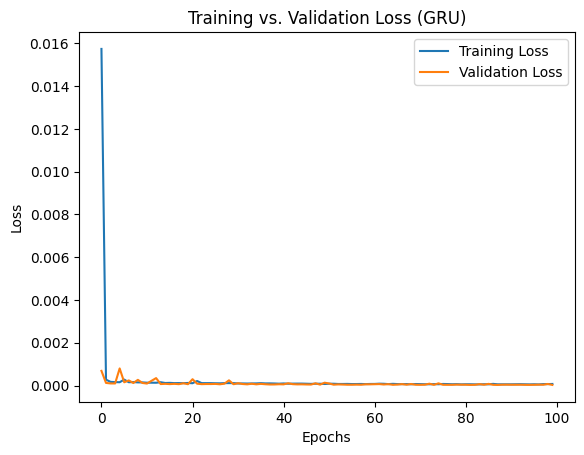

In [40]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs. Validation Loss (GRU)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step


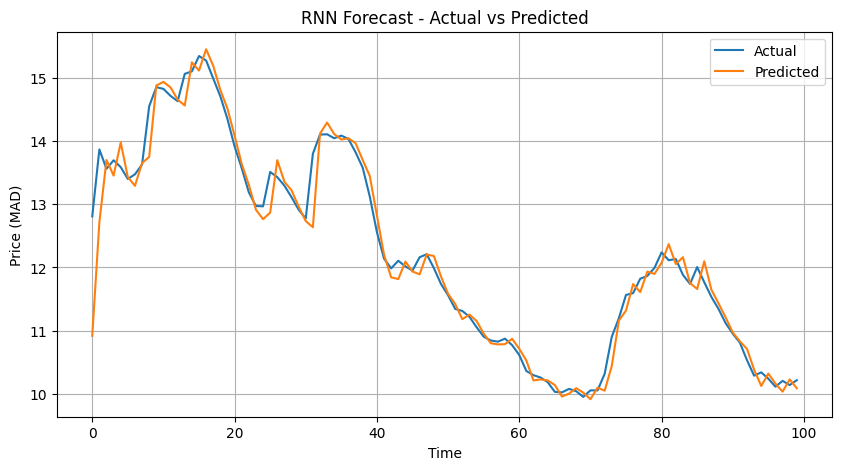

In [41]:
predictions = model.predict(X_test)


y_pred_inverse = scaler.inverse_transform(predictions)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1,1))

plt.figure(figsize=(10, 5))
plt.plot(y_test_inverse[:100], label='Actual')
plt.plot(y_pred_inverse[:100], label='Predicted')
plt.title("RNN Forecast - Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Price (MAD)")
plt.legend()
plt.grid(True)
plt.show()


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


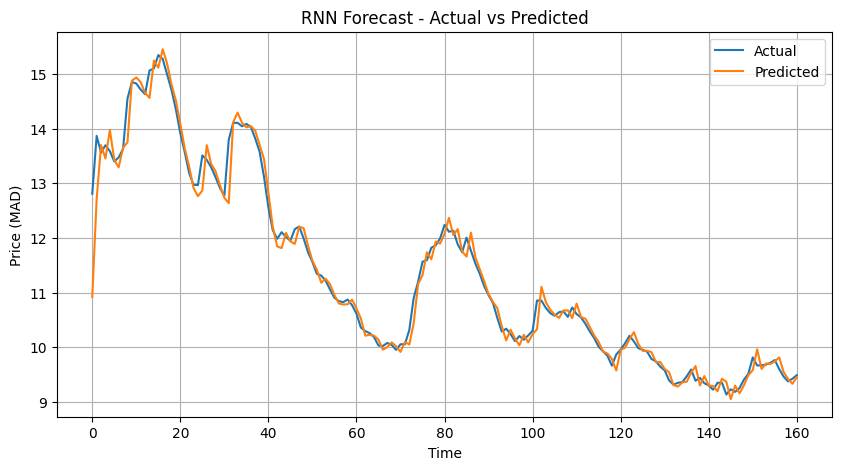

In [42]:
predictions = model.predict(X_test)


y_pred_inverse = scaler.inverse_transform(predictions)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1,1))

plt.figure(figsize=(10, 5))
plt.plot(y_test_inverse, label='Actual')
plt.plot(y_pred_inverse, label='Predicted')
plt.title("RNN Forecast - Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Price (MAD)")
plt.legend()
plt.grid(True)
plt.show()


In [43]:
from sklearn.metrics import r2_score

mse = np.mean((predictions - y_test) ** 2)
mae = np.mean(np.abs(predictions - y_test))
r2 = r2_score(y_test, predictions)

print(f"MSE (RNN): {mse:.4f}")
print(f"MAE (RNN): {mae:.4f}")
print(f"R² Score (RNN): {r2:.4f}")

MSE (RNN): 0.0004
MAE (RNN): 0.0117
R² Score (RNN): 0.9769


In [44]:
model.save('best_model_RNN_DieselPrice.h5')

<Figure size 2000x800 with 0 Axes>

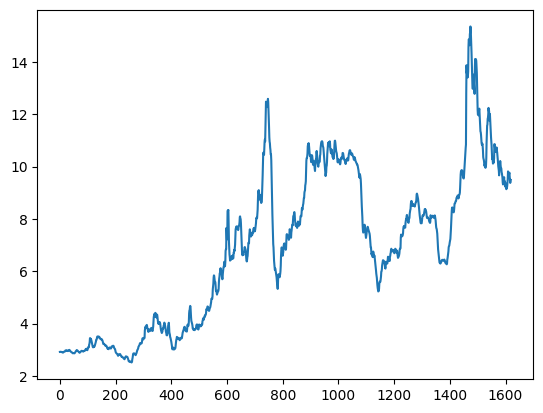

<Figure size 2000x800 with 0 Axes>

In [45]:
df['Price'].plot()
plt.figure(figsize = (20,8))